In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('Solarize_Light2')

# Exploratory Data Analysis

In this notebook, I am going to explore my transformed data and take a closer look at the variables, the relationships between them, and my target variable: `observed_exposure`.

In [8]:
data=pd.read_csv('../dataset/transformed_data.csv')
data.sample(5)

,occ_code,title,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,pct_computer,pct_physical,pct_communication,pct_analyze,pct_manage,pct_creative,pct_textnative,observed_exposure
392,37-1011,First-Line Supervisors of Housekeeping and Jan...,Building and Grounds Cleaning and Maintenance,1,0,2,39940.0,30400.0,0.000000,0.192308,0.500000,0.384615,0.384615,0.000000,0.038462,0.0436
159,19-4061,Social Science Research Assistants,"Life, Physical, and Social Science",1,0,4,46640.0,10600.0,0.228571,0.028571,0.371429,0.600000,0.200000,0.028571,0.285714,0.4393
731,53-5011,Sailors and Marine Oilers,Transportation and Material Moving,0,0,2,40900.0,4000.0,0.000000,0.428571,0.178571,0.107143,0.142857,0.000000,0.000000,0.0000
363,33-3012,Correctional Officers and Jailers,Protective Service,0,0,2,44330.0,33800.0,0.038462,0.038462,0.307692,0.269231,0.230769,0.000000,0.000000,0.0000
311,29-1242,"Orthopedic Surgeons, Except Pediatric",Healthcare Practitioners and Technical,1,0,5,71670.0,5000.0,0.044466,0.044466,0.565217,0.363636,0.125490,0.000000,0.000000,0.0000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   occ_code           756 non-null    object 
 1   title              756 non-null    object 
 2   JobFamily          756 non-null    object 
 3   isBright           756 non-null    int64  
 4   isGreen            756 non-null    int64  
 5   JobZone            756 non-null    int64  
 6   MedianSalary       756 non-null    float64
 7   JobForecast        756 non-null    float64
 8   pct_computer       756 non-null    float64
 9   pct_physical       756 non-null    float64
 10  pct_communication  756 non-null    float64
 11  pct_analyze        756 non-null    float64
 12  pct_manage         756 non-null    float64
 13  pct_creative       756 non-null    float64
 14  pct_textnative     756 non-null    float64
 15  observed_exposure  756 non-null    float64
dtypes: float64(10), int64(3), 

In [10]:
print(f'Number of rows: {data.shape[0]}')
print(f'Number of duplicates: {data.duplicated().sum()}')
print(f'Number of null values: {data.isnull().sum()}')

Number of rows: 756
Number of duplicates: 0
Number of null values: occ_code             0
title                0
JobFamily            0
isBright             0
isGreen              0
JobZone              0
MedianSalary         0
JobForecast          0
pct_computer         0
pct_physical         0
pct_communication    0
pct_analyze          0
pct_manage           0
pct_creative         0
pct_textnative       0
observed_exposure    0
dtype: int64


In [11]:
data.describe()

,isBright,isGreen,JobZone,MedianSalary,JobForecast,pct_computer,pct_physical,pct_communication,pct_analyze,pct_manage,pct_creative,pct_textnative,observed_exposure
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,0.425926,0.165344,3.068783,56350.945767,3.046858e+04,0.067958,0.193067,0.403020,0.330301,0.168408,0.027665,0.039609,0.076977
std,0.494810,0.371737,1.248269,26992.809291,9.010565e+04,0.089866,0.216542,0.216892,0.179452,0.151060,0.067870,0.057698,0.133172
min,0.000000,0.000000,0.000000,20120.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,36307.500000,2.200000e+03,0.000000,0.000000,0.229895,0.183612,0.052632,0.000000,0.000000,0.000000
50%,0.000000,0.000000,3.000000,50090.000000,5.300000e+03,0.044466,0.100000,0.390097,0.333333,0.125490,0.000000,0.000000,0.000000
75%,1.000000,0.000000,4.000000,71670.000000,1.845000e+04,0.100000,0.318994,0.565217,0.457440,0.250000,0.027778,0.064810,0.095675
max,1.000000,1.000000,5.000000,208000.000000,1.052000e+06,0.588235,0.900000,1.000000,1.000000,0.800000,0.588235,0.444444,0.745100


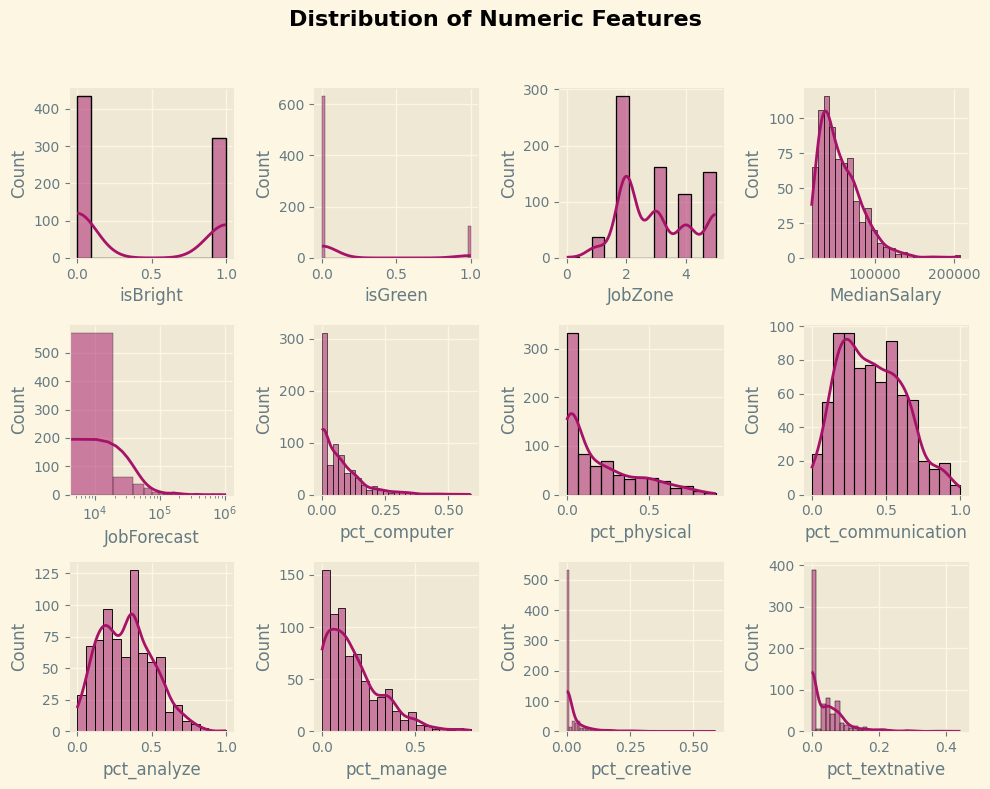

In [12]:
fig, axs=plt.subplots(nrows=3, ncols=4,figsize=(10,8))
axs=axs.flatten()

quantitative_vars=['isBright','isGreen', 'JobZone','MedianSalary','JobForecast','pct_computer','pct_physical','pct_communication','pct_analyze','pct_manage','pct_creative','pct_textnative']

for i, col in enumerate (quantitative_vars):
    sns.histplot(data[col], kde=True, ax=axs[i], color='#a61268', edgecolor='black')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')
    if col=='JobForecast':
        axs[i].set_xscale('log')

fig.suptitle("Distribution of Numeric Features", fontweight='bold', fontsize=16, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('../outputs/data-plots/numeric-features-distribution.png', dpi=300)

### Distribution Observations

- **isBright, isGreen:** Binary variables — roughly half of occupations are Bright, while only ~20% are Green.
- **JobZone:** Most occupations fall in zones 2–4, with very few in zone 1. The dataset underrepresents low-preparation jobs.
- **MedianSalary:** Right-skewed, with most occupations earning under $100K and a long tail of high-paying jobs. 
- **JobForecast:** Right-skewed with most occupations sitting between ~10³ and ~10⁴ projected jobs.
- **pct_computer, pct_physical, pct_creative, pct_textnative:** Heavily right-skewed — the majority of occupations have low values, meaning few tasks involve computers, creative work, or text.
- **pct_communication, pct_analyze, pct_manage:** More evenly spread, with `pct_physical` and `pct_communication` showing the widest range of values across occupations.

In [13]:
print(f'Number of occupation with 0% observed AI exposure: {(data[data.observed_exposure==0]).shape[0]} out of {data.shape[0]}')
print(f'Number of occupation with 1-10% observed AI exposure: {(data[(data.observed_exposure<=0.10)&(data.observed_exposure>=0.01)]).shape[0]} out of {data.shape[0]}')
print(f'Number of occupation with 11-30% observed AI exposure: {(data[(data.observed_exposure<=0.30)&(data.observed_exposure>=0.11)]).shape[0]} out of {data.shape[0]}')
print(f'Number of occupation with 31-50% observed AI exposure: {(data[(data.observed_exposure<=0.50)&(data.observed_exposure>=0.31)]).shape[0]} out of {data.shape[0]}')
print(f'Number of occupation with 51-70% observed AI exposure: {(data[(data.observed_exposure<=0.70)&(data.observed_exposure>=0.51)]).shape[0]} out of {data.shape[0]}')
print(f'Number of occupation with 71-100% observed AI exposure: {(data[(data.observed_exposure<=1)&(data.observed_exposure>=0.71)]).shape[0]} out of {data.shape[0]}')

Number of occupation with 0% observed AI exposure: 411 out of 756
Number of occupation with 1-10% observed AI exposure: 156 out of 756
Number of occupation with 11-30% observed AI exposure: 105 out of 756
Number of occupation with 31-50% observed AI exposure: 51 out of 756
Number of occupation with 51-70% observed AI exposure: 8 out of 756
Number of occupation with 71-100% observed AI exposure: 1 out of 756


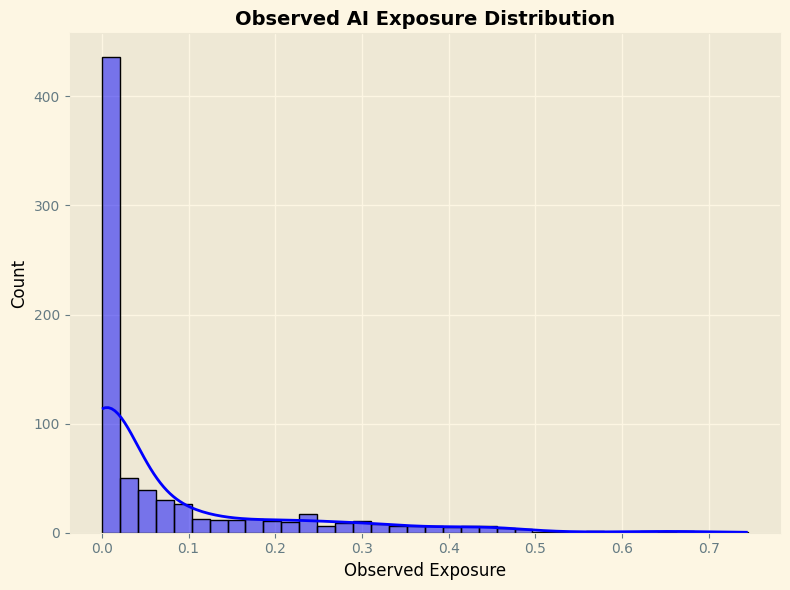

In [14]:
# plotting the distribution of AI exposure score
fig, ax=plt.subplots(figsize=(8,6))

title_style={'weight':'bold', 'size':14, 'color':'black'}
text_style={'color':'black', 'size':12}

ax.set_title('Observed AI Exposure Distribution', fontdict=title_style)
sns.histplot(data.observed_exposure, kde=True, color='blue')
ax.set_xlabel('Observed Exposure', fontdict=text_style)
ax.set_ylabel('Count', fontdict=text_style)

plt.tight_layout()

plt.savefig('../outputs/data-plots/observed-ai-exposure-distribution.png', dpi=300)

## Data Visualization
Now I am going to visualize the relationships between each numerical feature and the target variable `observed_exposure`.

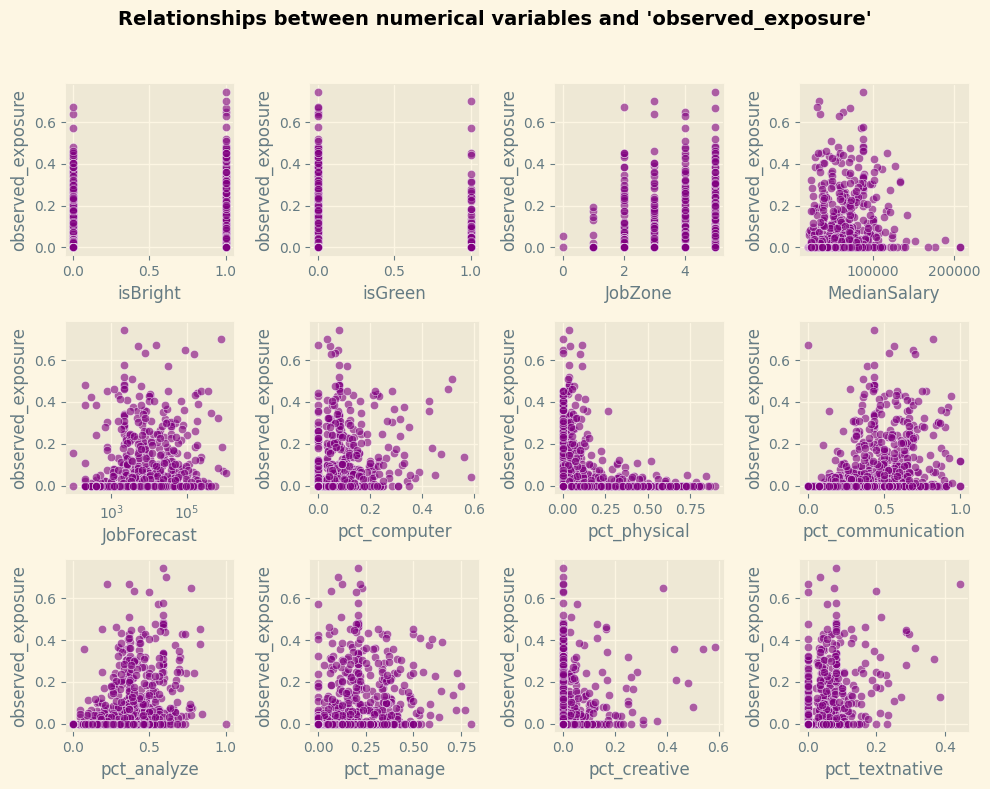

In [15]:
fig, axs=plt.subplots(nrows=3, ncols=4, figsize=(10,8))
axs=axs.flatten()

quantitative_vars=['isBright','isGreen', 'JobZone','MedianSalary','JobForecast','pct_computer','pct_physical','pct_communication','pct_analyze','pct_manage','pct_creative','pct_textnative']

for i, var in enumerate(quantitative_vars):
    sns.scatterplot(data=data, x=var, y='observed_exposure', color='purple', ax=axs[i], alpha=0.6)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('observed_exposure')
    if var=='JobForecast':
        axs[i].set_xscale('log')

fig.suptitle("Relationships between numerical variables and 'observed_exposure'", fontweight='bold', fontsize=14, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('../outputs/data-plots/feature_vs_exposure_all_occupations.png', dpi=300)

The plots above include all occupations, but over half have exactly zero AI exposure, creating a dense cluster at the bottom of each subplot. To get a clearer view of the relationships, I will filter to only non-zero occupations and use `regplot` to overlay a linear trend line. The relationships are visible but moderate — this is expected for social science and the fact the features depend solely on the semantics of O*NET tasks. No single feature will produce a tight linear pattern because AI exposure depends on the complex interplay of many occupational characteristics.

## Dropping data with zero AI exposure
Filtering data to occupations only with non-zero exposure data will allow me to better identify present trends and relationships

In [16]:
nonzero_data=data.copy()
nonzero_data=nonzero_data[~(nonzero_data.observed_exposure==0)]

In [17]:
nonzero_data.describe()

,isBright,isGreen,JobZone,MedianSalary,JobForecast,pct_computer,pct_physical,pct_communication,pct_analyze,pct_manage,pct_creative,pct_textnative,observed_exposure
count,345.000000,345.000000,345.000000,345.000000,3.450000e+02,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000
mean,0.472464,0.185507,3.579710,64397.922319,4.373652e+04,0.105047,0.086476,0.491338,0.418483,0.221990,0.039144,0.065844,0.168679
std,0.499966,0.389273,1.212889,27200.256496,1.186141e+05,0.104857,0.140584,0.193587,0.162649,0.158062,0.087919,0.068350,0.153004
min,0.000000,0.000000,0.000000,22160.000000,1.000000e+02,0.000000,0.000000,0.000000,0.041667,0.000000,0.000000,0.000000,0.002200
25%,0.000000,0.000000,2.000000,40660.000000,2.700000e+03,0.040000,0.000000,0.350000,0.315789,0.105263,0.000000,0.000000,0.046600
50%,0.000000,0.000000,4.000000,62580.000000,8.400000e+03,0.081169,0.035714,0.479167,0.400000,0.200000,0.000000,0.054545,0.109600
75%,1.000000,0.000000,5.000000,82220.000000,3.090000e+04,0.136364,0.105263,0.631579,0.533333,0.333333,0.035714,0.083333,0.249000
max,1.000000,1.000000,5.000000,189600.000000,1.052000e+06,0.588235,0.846154,1.000000,0.842105,0.769231,0.588235,0.444444,0.745100


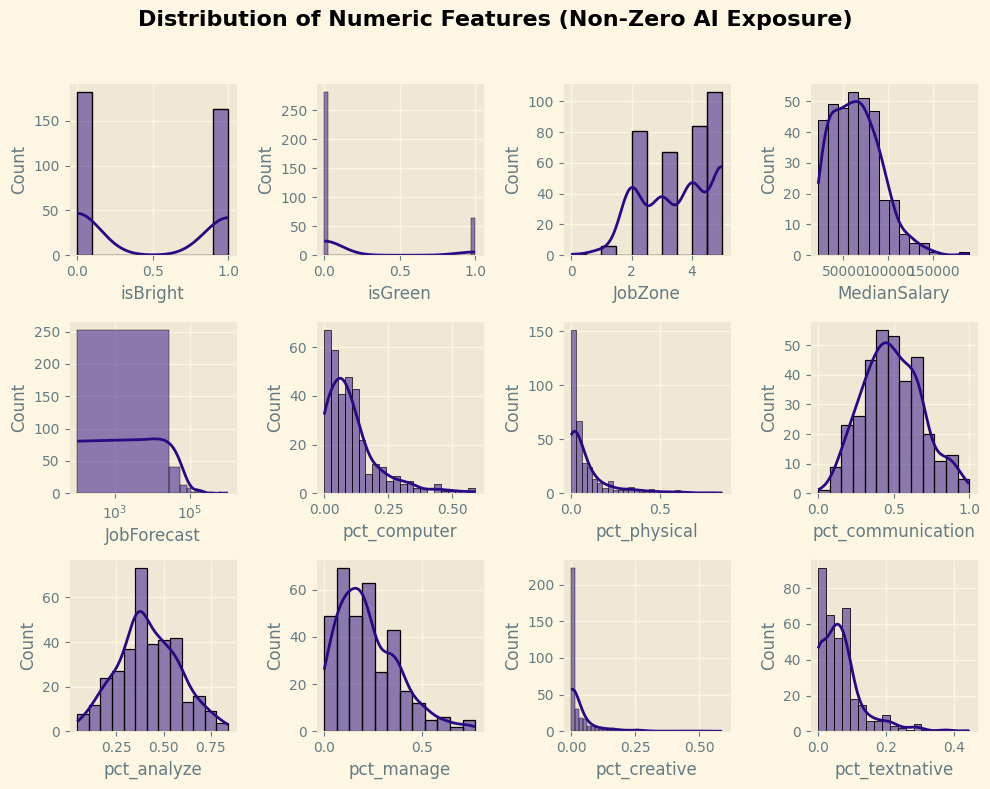

In [18]:
fig, axs=plt.subplots(nrows=3, ncols=4,figsize=(10,8))
axs=axs.flatten()

quantitative_vars=['isBright','isGreen', 'JobZone','MedianSalary','JobForecast','pct_computer','pct_physical','pct_communication','pct_analyze','pct_manage','pct_creative','pct_textnative']

for i, col in enumerate (quantitative_vars):
    sns.histplot(nonzero_data[col], kde=True, ax=axs[i], color="#290A85", edgecolor='black')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')
    if col=='JobForecast':
        axs[i].set_xscale('log')

fig.suptitle("Distribution of Numeric Features (Non-Zero AI Exposure)", fontweight='bold', fontsize=16, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('../outputs/data-plots/numeric-features-distribution-nonzero.png', dpi=300)

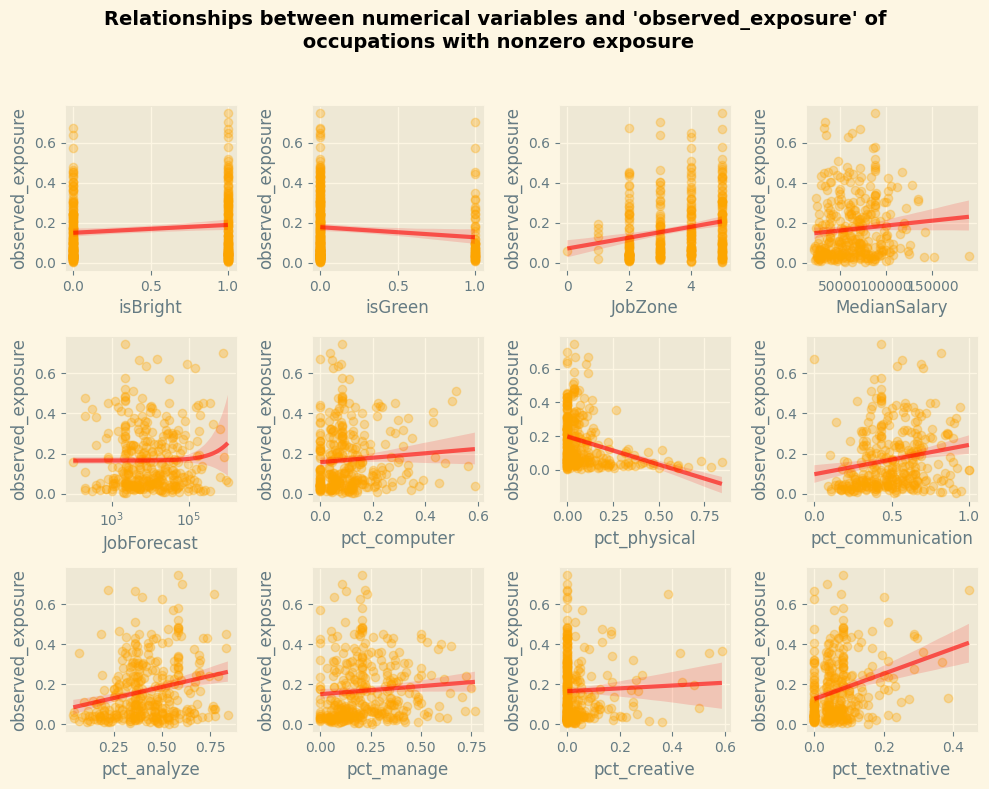

In [19]:
fig, axs=plt.subplots(nrows=3, ncols=4, figsize=(10,8))
axs=axs.flatten()

quantitative_vars=['isBright','isGreen', 'JobZone','MedianSalary','JobForecast','pct_computer','pct_physical','pct_communication','pct_analyze','pct_manage','pct_creative','pct_textnative']

for i, var in enumerate(quantitative_vars):
    sns.regplot(data=nonzero_data, x=var, y='observed_exposure', color='orange', line_kws={"alpha": 0.6, "color": "red"},scatter_kws={"alpha": 0.3}, ax=axs[i])
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('observed_exposure')
    if var=='JobForecast':
        axs[i].set_xscale('log')

fig.suptitle("Relationships between numerical variables and 'observed_exposure' of\n occupations with nonzero exposure", fontweight='bold', fontsize=14, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('../outputs/data-plots/feature_vs_exposure_nonzero-only.png', dpi=300)

In [20]:
n_rows=nonzero_data.shape[0]
# isBright
is_Bright=nonzero_data[nonzero_data.isBright==1]
is_not_Bright=nonzero_data[nonzero_data.isBright==0]
print(f'isBright: {(is_Bright.shape[0]/n_rows)*100}% Bright vs. {(is_not_Bright.shape[0]/n_rows)*100}% not Bright')
print(f'observed_exposure>=0.5: {round((is_Bright[is_Bright.observed_exposure>=0.5].shape[0]/is_Bright.shape[0])*100, 2)}% of Bright')
print(f'observed_exposure>=0.5: {round((is_not_Bright[is_not_Bright.observed_exposure>=0.5].shape[0]/is_not_Bright.shape[0])*100,2)}% of not Bright\n')

# isGreen
is_Green=nonzero_data[nonzero_data.isGreen==1]
is_not_Green=nonzero_data[nonzero_data.isGreen==0]
print(f'isGreen: {(is_Green.shape[0]/n_rows)*100}% Green vs. {(is_not_Bright.shape[0]/n_rows)*100} not Green')
print(f'observed_exposure>=0.5: {round((is_Green[is_Green.observed_exposure>=0.5].shape[0]/is_Green.shape[0])*100,2)}% of Green')
print(f'observed_exposure>=0.5: {round((is_not_Green[is_not_Green.observed_exposure>=0.5].shape[0]/is_not_Green.shape[0])*100,2)}% of Green\n')

JobZone_0_1=nonzero_data.query('JobZone<1 and JobZone>=0')
JobZone_1_2=nonzero_data.query('JobZone<2 and JobZone>=1')
JobZone_2_3=nonzero_data.query('JobZone<3 and JobZone>=2')
JobZone_3_4=nonzero_data.query('JobZone<4 and JobZone>=3')
JobZone_4_5=nonzero_data.query('JobZone<5 and JobZone>=4')
print('JobZone:')
print(f'0-1: {round((JobZone_0_1.shape[0]/n_rows)*100,2)}%\n1-2: {round((JobZone_1_2.shape[0]/n_rows)*100,2)}%')
print(f'2-3: {round((JobZone_2_3.shape[0]/n_rows)*100,2)}%\n3-4: {round((JobZone_3_4.shape[0]/n_rows)*100,2)}%')
print(f'4-5: {round((JobZone_4_5.shape[0]/n_rows)*100,2)}%\n')

print(f'observed_exposure>=0.5: {round((JobZone_0_1[JobZone_0_1.observed_exposure>=0.5].shape[0]/JobZone_0_1.shape[0])*100,2)}% — JobZone between 0 and 1')
print(f'observed_exposure>=0.5: {round((JobZone_1_2[JobZone_1_2.observed_exposure>=0.5].shape[0]/JobZone_1_2.shape[0])*100,2)}% — JobZone between 1 and 2')
print(f'observed_exposure>=0.5: {round((JobZone_2_3[JobZone_2_3.observed_exposure>=0.5].shape[0]/JobZone_2_3.shape[0])*100,2)}% — JobZone between 2 and 3')
print(f'observed_exposure>=0.5: {round((JobZone_3_4[JobZone_3_4.observed_exposure>=0.5].shape[0]/JobZone_3_4.shape[0])*100,2)}% — JobZone between 3 and 4')
print(f'observed_exposure>=0.5: {round((JobZone_4_5[JobZone_4_5.observed_exposure>=0.5].shape[0]/JobZone_4_5.shape[0])*100,2)}% — JobZone between 4 and 5')

isBright: 47.2463768115942% Bright vs. 52.7536231884058% not Bright
observed_exposure>=0.5: 4.91% of Bright
observed_exposure>=0.5: 1.65% of not Bright

isGreen: 18.55072463768116% Green vs. 52.7536231884058 not Green
observed_exposure>=0.5: 3.12% of Green
observed_exposure>=0.5: 3.2% of Green

JobZone:
0-1: 0.29%
1-2: 1.74%
2-3: 23.48%
3-4: 19.42%
4-5: 24.35%

observed_exposure>=0.5: 0.0% — JobZone between 0 and 1
observed_exposure>=0.5: 0.0% — JobZone between 1 and 2
observed_exposure>=0.5: 1.23% — JobZone between 2 and 3
observed_exposure>=0.5: 2.99% — JobZone between 3 and 4
observed_exposure>=0.5: 4.76% — JobZone between 4 and 5


## Observations
The following analysis covers only occupations with non-zero AI exposure, since zero-exposure occupations were dropped for clearer visualization. These observations are exploratory — they suggest patterns but do not establish causation.

- **isBright:** Hard to see a clear relationship visually. However, computing relative percentages shows that Bright occupations are somewhat more likely to have high exposure (4.91% vs. 1.65% with exposure ≥ 0.5).

- **isGreen:** No meaningful difference — both Green and non-Green occupations show ~3% with high exposure.

- **JobZone:** Clear positive trend — higher education requirements correlate with higher AI exposure. However, low-preparation jobs (JobZone 1–2) make up less than 5% of this subset, so the dataset underrepresents these occupations.

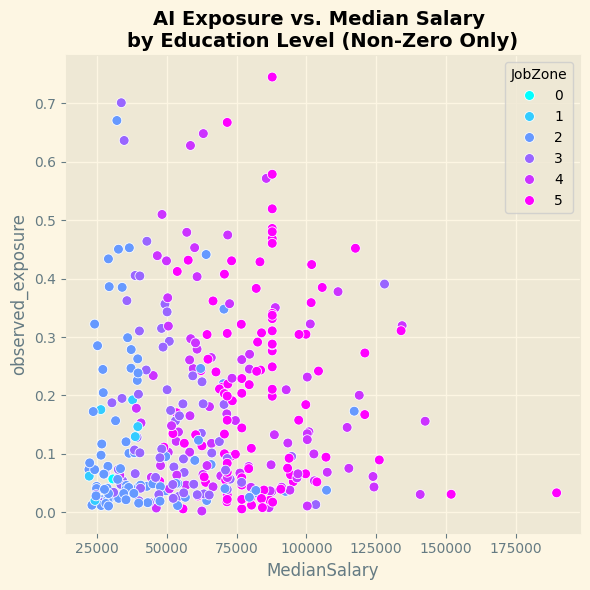

In [21]:
fig, ax=plt.subplots(figsize=(6,6))

sns.scatterplot(data=nonzero_data, x='MedianSalary', y='observed_exposure', hue='JobZone', s=50, palette='cool')
ax.set_title('AI Exposure vs. Median Salary \nby Education Level (Non-Zero Only)', fontdict=title_style)

plt.tight_layout()
plt.savefig('../outputs/data-plots/exposure-vs-salary-by-jobzone.png', dpi=300)

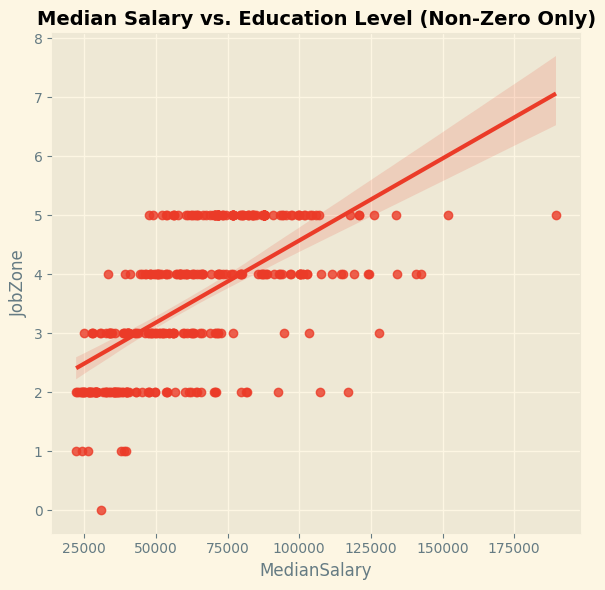

In [22]:
fig, ax=plt.subplots(figsize=(6,6))

sns.regplot(data=nonzero_data, x='MedianSalary', y='JobZone', color='#eb3b28', scatter_kws={'alpha':0.8})
ax.set_title('Median Salary vs. Education Level (Non-Zero Only)', fontdict=title_style)

plt.tight_layout()
plt.savefig('../outputs/data-plots/salary-vs-jobzone.png', dpi=300)

- **MedianSalary:** Slight positive correlation, likely connected to JobZone — higher-preparation jobs tend to pay more and have more AI exposure. The salary-vs-JobZone plot confirms these two features are positively correlated, which is worth watching for multicollinearity during modeling.

- **JobForecast:** The regression line is mostly stable with a slight upward at the very end, which may suggest that the biggest occupations (with more workers) may experience higher AI exposure. However, no clear relationship may be established.

- **pct_computer:** Strongest positive predictor in the dataset. Occupations with more computer-related tasks have clearly higher AI exposure.
- **pct_physical:** Clear negative relationship — physically-intensive occupations have lower AI exposure.
- **pct_communication, pct_analyze:** Both show moderate positive trends, consistent with AI being used more in knowledge and analytical work.
- **pct_manage, pct_creative** Weaker or less clear relationships.
- **pct_textnative:** Strong visible positive relationship. 

## Correlation Heatmap
To quantify the relationships observed in the scatter plots above, I construct a correlation heatmap. This also reveals multicollinearity between input features, which is important to account for when interpreting model coefficients.

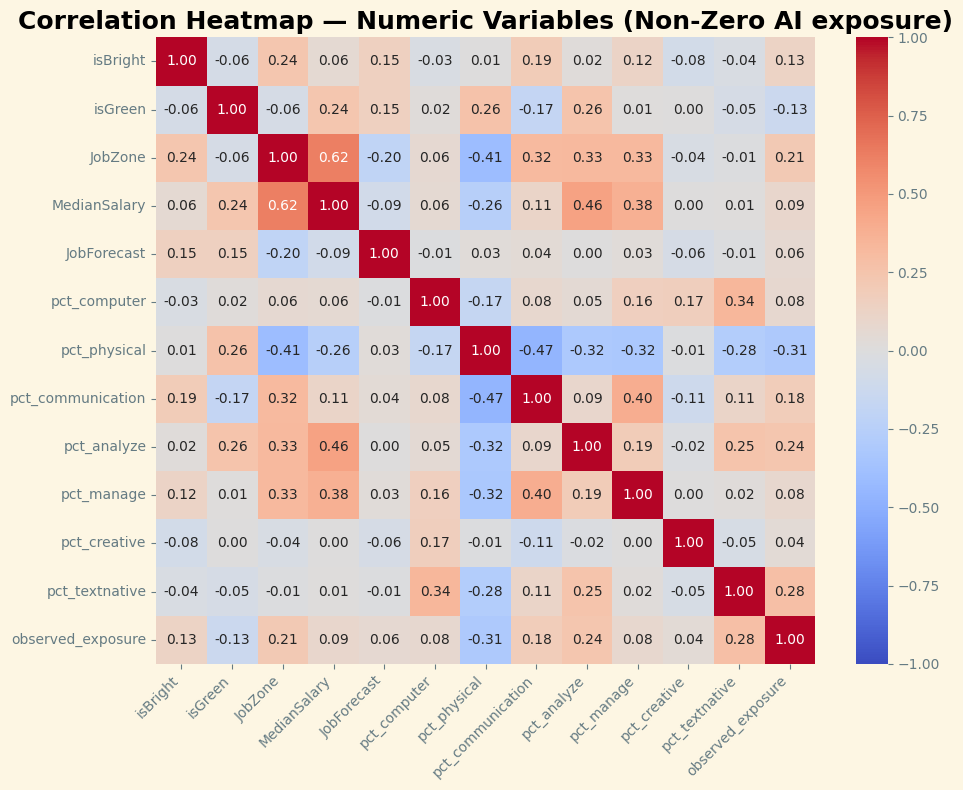

In [23]:
correlation=nonzero_data.corr(numeric_only=True)

fig, ax=plt.subplots(figsize=(10,8))
sns.heatmap(correlation, annot=True, fmt='.2f',vmin=-1, vmax=1, cmap='coolwarm')

plt.tick_params(axis='x',rotation=45 )
ax=plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), ha='right')

ax.set_title('Correlation Heatmap — Numeric Variables (Non-Zero AI exposure)', fontdict={'weight':'bold', 'size':18})
plt.tight_layout()
plt.savefig('../outputs/data-plots/correlation-heatmap-nonzero.png', dpi=300)

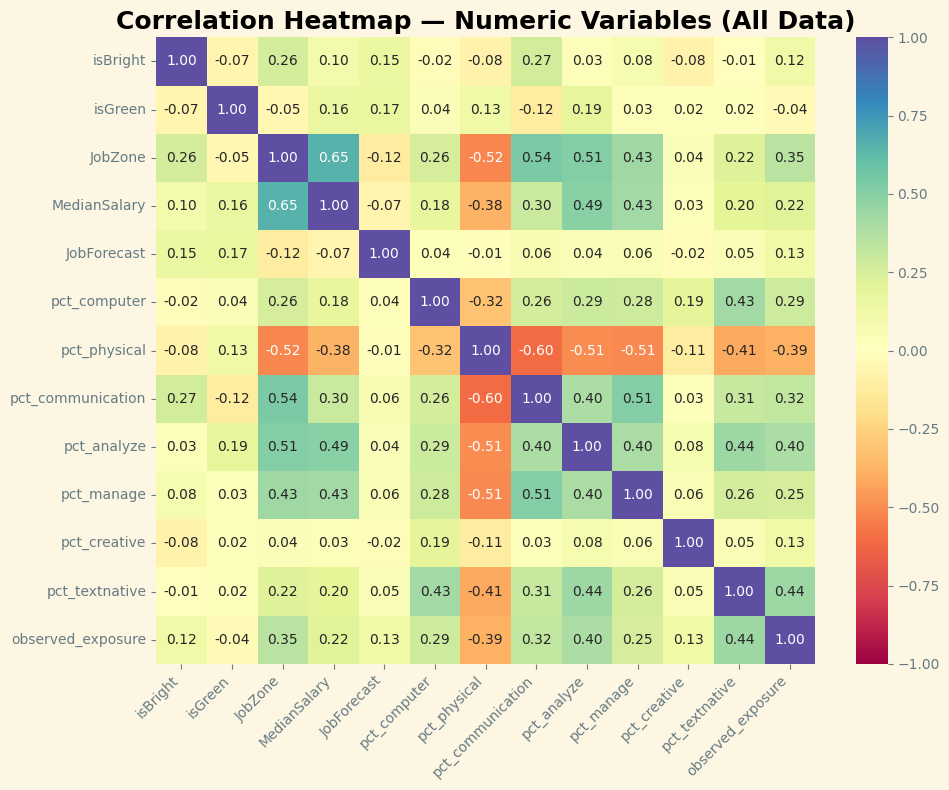

In [24]:
correlation=data.corr(numeric_only=True)

fig, ax=plt.subplots(figsize=(10,8))
sns.heatmap(correlation, annot=True, fmt='.2f',vmin=-1, vmax=1, cmap='Spectral')

plt.tick_params(axis='x',rotation=45 )
ax=plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), ha='right')

ax.set_title('Correlation Heatmap — Numeric Variables (All Data)', fontdict={'weight':'bold', 'size':18})
plt.tight_layout()
plt.savefig('../outputs/data-plots/correlation-heatmap-all-data.png', dpi=300)

## Heatmap Observations

**Full dataset (with zeros):** The strongest correlates with `observed_exposure` are `JobZone` (+0.35), `pct_computer` (+0.29), `pct_physical` (−0.39), `pct_communication` (+0.32),`pct_analyze` (+0.40), `pct_manage` (+0.25), and `pct_textnative` (+0.44).

**Non-zero subset only:** All correlations weaken substantially — `pct_physical` changes to −0.31, `pct_textnative` to +0.28, `pct_analyze` to +0.24, and `pct_computer` drops from +0.29 to just +0.08. This tells us that these features are especially useful for distinguishing zero vs. non-zero exposure.

Notable multicollinearity between input features:
- `JobZone` and `MedianSalary` (+0.65) — higher education requirements correlate with higher pay
- `pct_physical` correlates negatively with nearly every knowledge-work feature: `pct_analyze` (−0.51), `pct_manage` (−0.51), `pct_communication` (−0.60), `pct_textnative` (−0.41) — occupations are either physical or knowledge-oriented, not both
- `pct_communication` and `JobZone` (+0.54) / `pct_manage` (+0.51) — higher-level jobs involve more communication and management
- `pct_computer` and `pct_textnative` (+0.43) — text-heavy work often involves computers

The task-content features are broadly intercorrelated because they partition an occupation's work profile — an occupation's individual charachteristics may vary depending on the nature of tasks/preparation involved.

## Dropping `JobForecast`

Although `JobForecast` was loaded and merged alongside the other wage features, I drop it from the final feature set for two reasons.

First, it is difficult to interpret substantively. The column reports projected absolute job openings rather than a growth rate, and the raw count is dominated by the size of the occupation itself: a 2% expansion of a bigger occupation produces a far larger `JobForecast` than a 30% expansion of a smaller one. Recovering real growth would require current employment counts per SOC code, which aren't included in the wage data and are non-trivial to source consistently.

Second, `JobForecast` carries little relational signal. It has negligible correlation with any of the other numeric features and only a weak correlation (r ≈ 0.13) with `observed_exposure` and sits almost entirely in the upper tail of the distribution. That makes it more likely to introduce noise than to surface a useful pattern. 

In [25]:
data.drop(columns=['JobForecast'], inplace=True)

In [26]:
data.to_csv('../dataset/transformed_data.csv', index=False)